In [1]:
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from datetime import datetime as dt

In [15]:
df = pd.read_csv("/Users/saraseid/Desktop/citibike-weather-project/weather_daily_2022.csv")
df.head()

,date,TMAX,TMIN,tmax_c,tmin_c,avg_temp_c
0,2022-01-01,13.3,10.0,1.33,1.00,1.165
1,2022-01-02,15.0,2.8,1.50,0.28,0.890
2,2022-01-03,2.8,-5.5,0.28,-0.55,-0.135
3,2022-01-04,1.1,-7.1,0.11,-0.71,-0.300
4,2022-01-05,8.3,-0.5,0.83,-0.05,0.390


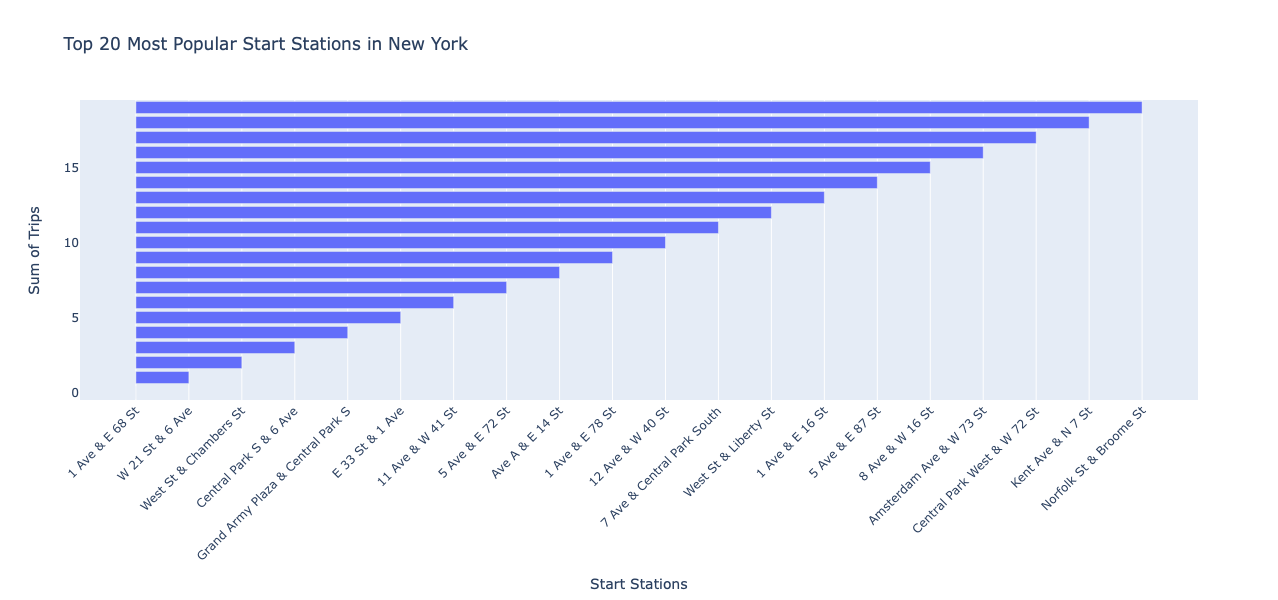

In [18]:
import pandas as pd
import plotly.graph_objects as go

# Load  data
df = pd.read_csv("/Users/saraseid/Desktop/citibike-weather-project/routes_top500.csv")

# Top 20 most popular start stations
df["value"] = 1
df_group = df.groupby("start_station_name", as_index=False).agg({"value": "sum"})
top20 = df_group.nlargest(20, "value")

# Plotly bar chart
fig = go.Figure(
    go.Bar(
        x=top20["start_station_name"],
        y=top20["value"],
        marker={"color": top20["value"], "colorscale": "Blues"},
        hovertemplate="Station: %{x}<br>Trips: %{y:,}<extra></extra>"
    )
)

fig.update_layout(
    title="Top 20 Most Popular Start Stations in New York",
    xaxis_title="Start Stations",
    yaxis_title="Sum of Trips",
    width=900,
    height=600
)

# Rotate x labels
fig.update_xaxes(tickangle=-45)

fig.show()

# Save for Streamlit
top20.to_csv("top20.csv", index=False)

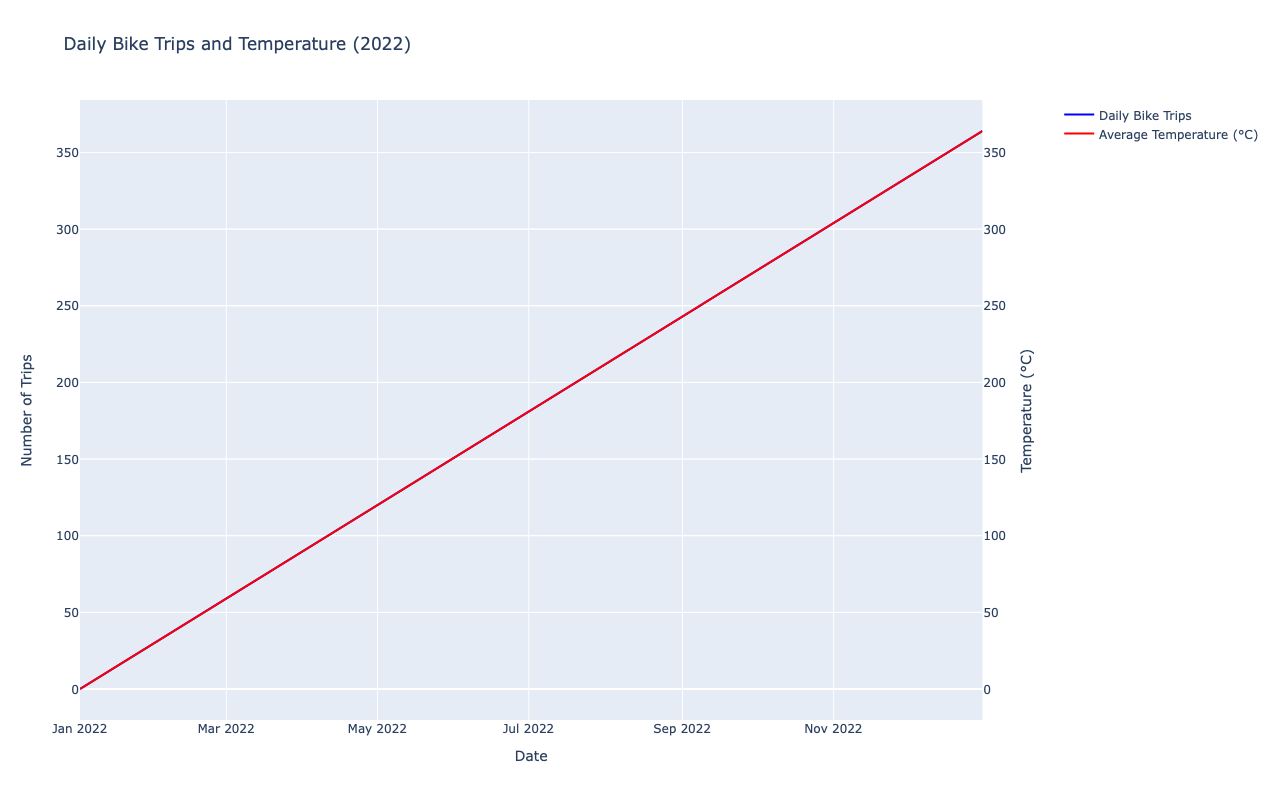

In [31]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Load aggregated data
df = pd.read_csv("reduced_data_to_plot.csv")
df["date"] = pd.to_datetime(df["date"])

# Create dual-axis figure
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Bike trips (left axis)
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["bike_rides_daily"],
        name="Daily Bike Trips",
        line=dict(color="blue")
    ),
    secondary_y=False
)

# Temperature (right axis)
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["avgTemp"],
        name="Average Temperature (°C)",
        line=dict(color="red")
    ),
    secondary_y=True
)

# Layout
fig.update_layout(
    title="Daily Bike Trips and Temperature (2022)",
    xaxis_title="Date",
    height=800
)

fig.update_yaxes(title_text="Number of Trips", secondary_y=False)
fig.update_yaxes(title_text="Temperature (°C)", secondary_y=True)

fig.show()

In [34]:
import streamlit as st
import pandas as pd
import plotly.graph_objects as go

# Page config
st.set_page_config(page_title="Citi Bike Dashboard", layout="wide")

# Title
st.title("Citi Bike Trips & Temperature Dashboard")

# Load data
df = pd.read_csv("reduced_data_to_plot.csv")
df["date"] = pd.to_datetime(df["date"])

# Dual-axis line chart
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["bike_rides_daily"],
        name="Daily Bike Trips",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["avgTemp"],
        name="Average Temperature (°C)",
        yaxis="y2"
    )
)

fig.update_layout(
    xaxis_title="Date",
    yaxis=dict(title="Bike Trips"),
    yaxis2=dict(
        title="Temperature (°C)",
        overlaying="y",
        side="right"
    )
)

st.plotly_chart(fig, use_container_width=True)

2026-02-21 15:02:01.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:02:01.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [36]:
import streamlit as st

# Configure page
st.set_page_config(
    page_title="Citi Bike Strategy Dashboard",
    layout="wide"
)

# Dashboard title
st.title("Citi Bike Strategy Dashboard")

# Descriptive text
st.markdown(
    """
    This dashboard explores Citi Bike usage patterns in New York by analyzing
    aggregated daily bike trips alongside weather conditions.
    The goal is to support strategic insights related to demand and seasonal trends.
    """
)

2026-02-21 15:11:01.106 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.108 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.112 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:11:01.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [38]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import streamlit as st

# ---------- Load data ----------
df = pd.read_csv("reduced_data_to_plot.csv")
df["date"] = pd.to_datetime(df["date"])

top20 = pd.read_csv("top20.csv")

# ---------- Bar chart: Top 20 stations ----------
bar_fig = go.Figure(
    go.Bar(
        x=top20["start_station_name"],
        y=top20["value"],
        marker={"color": top20["value"], "colorscale": "Blues"}
    )
)

bar_fig.update_layout(
    title="Top 20 Most Popular Start Stations in New York",
    xaxis_title="Start Station",
    yaxis_title="Number of Trips",
    height=600
)

st.plotly_chart(bar_fig, use_container_width=True)

# ---------- Dual-axis line chart ----------
line_fig = make_subplots(specs=[[{"secondary_y": True}]])

line_fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["bike_rides_daily"],
        name="Daily Bike Trips",
        line=dict(color="blue")
    ),
    secondary_y=False
)

line_fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["avgTemp"],
        name="Average Temperature (°C)",
        line=dict(color="red")
    ),
    secondary_y=True
)

line_fig.update_layout(
    title="Daily Bike Trips and Temperature (2022)",
    xaxis_title="Date",
    height=800
)

line_fig.update_yaxes(title_text="Number of Trips", secondary_y=False)
line_fig.update_yaxes(title_text="Temperature (°C)", secondary_y=True)

st.plotly_chart(line_fig, use_container_width=True)

2026-02-21 15:22:07.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:22:07.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [44]:
import streamlit as st

st.header("Aggregated Bike Trips Map")

with open("nyc_trips_kepler_map.html", "r") as f:
    html_data = f.read()

st.components.v1.html(html_data, height=1000)

2026-02-21 15:56:04.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:56:04.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:56:04.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:56:04.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:56:04.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-21 15:56:04.705 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()